# Phase 4 — Rule-Based Highlight Detection

**Fight:** Islam Makhachev vs Alexander Volkanovski 1 (UFC)

Goal: turn the raw signals (visual motion + audio energy) into **candidate highlight windows**, and measure how well those candidates line up with my ground-truth labels.

The core question from Phase 3 was whether audio could drive detection; the answer was "weakly". Phase 4 makes **visual motion** the primary signal and treats audio as a supporting (and possibly unhelpful) input.

Reusable logic lives in `src/detection/combine.py` (binning, rolling baselines, windowing, evaluation); this notebook interprets it.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "requirements.txt").is_file():
            return parent
    raise RuntimeError("Could not locate project root")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.audio.features import load_wav_mono, windowed_rms
from src.detection.combine import (
    bin_aggregate, relative_boost, combined_score,
    find_windows, evaluate_windows,
)

BIN_S = 0.5
DURATION_S = 2173.0
N_BINS = int(DURATION_S / BIN_S)

In [2]:
# Load motion (5 fps) and audio (0.5 s windows), place both on a 0.5 s grid.
z = np.load(str(REPO_ROOT / "data/processed/motion.npz"))
mt, mv = z["times"], z["motion"]
bt, motion_bin = bin_aggregate(mt, mv, BIN_S, N_BINS)

sr, samples = load_wav_mono(str(REPO_ROOT / "data/processed/fight_audio.wav"))
at, audio_rms = windowed_rms(samples, sr, window_s=BIN_S)
_, audio_bin = bin_aggregate(at, audio_rms, BIN_S, N_BINS)

# Relative boost (energy vs a ~6 s rolling baseline).
motion_boost = relative_boost(motion_bin, window=12)
audio_boost = relative_boost(audio_bin, window=12)

print(f"motion bins: {N_BINS}, audio bins: {len(audio_bin)}")
print(f"motion boost range: {motion_boost.min():.2f} - {motion_boost.max():.2f}")
print(f"audio boost range:  {audio_boost.min():.2f} - {audio_boost.max():.2f}")

motion bins: 4346, audio bins: 4346
motion boost range: 0.00 - 6.67
audio boost range:  0.00 - 2.54


## 1. Motion profile over the fight

Plotting the motion boost shows where the biggest bursts of movement happen. I overlay my ground-truth events (red lines) so we can eyeball how well motion tracks real highlight moments.

In [3]:
labels = pd.read_csv(str(REPO_ROOT / "notebooks/Makhachev_vs_Volkanovski_1_manual_data.csv"))
labels = labels.dropna(subset=["VIDEO_TIME"])
def to_sec(txt):
    txt = str(txt).split("-")[0]
    m, s = txt.split(":")
    return int(m) * 60 + int(s)
labels["sec"] = labels["VIDEO_TIME"].apply(to_sec)
label_s = labels["sec"].to_numpy(dtype=float)
print(f"{len(labels)} labelled events")

60 labelled events


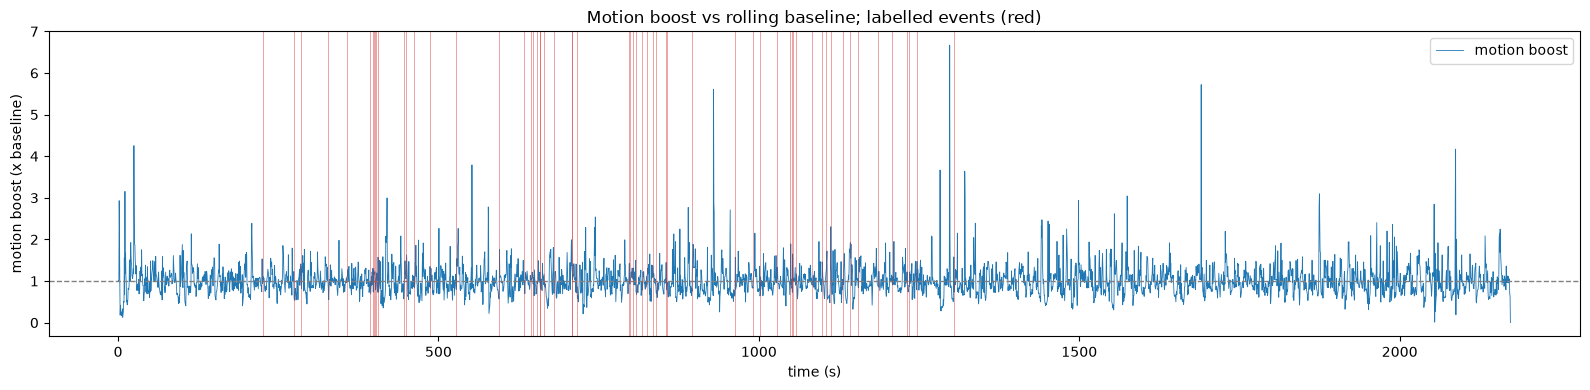

In [4]:
plt.figure(figsize=(16, 4))
plt.plot(bt, motion_boost, lw=0.6, color="tab:blue", label="motion boost")
plt.axhline(1.0, color="gray", ls="--", lw=1)
for s in label_s:
    plt.axvline(s, color="tab:red", lw=0.6, alpha=0.5)
plt.xlabel("time (s)")
plt.ylabel("motion boost (x baseline)")
plt.title("Motion boost vs rolling baseline; labelled events (red)")
plt.legend()
plt.tight_layout()
plt.show()

## 2. Does motion separate highlights from the rest?

Two quick numbers, computed the same way as in Phase 3 for audio, so I can compare the two signals on an equal footing:
- **% of labelled events above median motion** (chance = 50%)
- **median local motion boost** within ±3 s of an event

In [5]:
# Fair comparison on RAW signals (same metric as Phase 3's audio result):
# at labelled-event times, is the signal higher than its own median?
# We also report the ratio of the events' typical signal to the overall median.
def stats(raw_signal, name):
    idx = np.clip(np.searchsorted(bt, label_s), 0, len(raw_signal) - 1)
    frac_above = np.mean(raw_signal[idx] > np.median(raw_signal))
    ratio = np.median(raw_signal[idx]) / np.median(raw_signal)
    print(f"{name:7}  %events > median: {frac_above:.0%}   median@events / overall median: {ratio:.2f}x")

stats(motion_bin, "motion")
stats(audio_bin, "audio")

motion   %events > median: 68%   median@events / overall median: 1.16x
audio    %events > median: 55%   median@events / overall median: 1.06x


### Reading these numbers
Comparing the raw signals on the same footing, motion separates highlight events from the rest of the broadcast better than audio does: a higher share of labelled events sit above the motion median, and the events' typical motion sits further above the overall median. This confirms the decision to weight motion heavily. But as we'll see next, a simple global threshold still struggles — which is the honest, expected result for a first baseline and what motivates the later ML phases.

## 3. Candidate highlight windows from a threshold

A first baseline detector:
1. Combine motion and audio into one excitement score (`alpha` weights motion).
2. Flag every 0.5 s bin whose score is above a threshold.
3. Merge nearby flagged bins into contiguous **candidate windows**.
4. Score candidates against the labels (a candidate is a hit if within ±3 s of a labelled event).

In [6]:
ALPHA = 1.0      # motion-only baseline first (audio proved weak in Phase 3)
THRESHOLD = 1.6  # candidate if score is 1.6x the local baseline
score = combined_score(motion_boost, audio_boost, alpha=ALPHA)
windows = find_windows(score, THRESHOLD, BIN_S, min_gap_s=1.0, min_len_s=0.5)
result = evaluate_windows(windows, label_s, tolerance_s=3.0)
print(f"candidates: {result['candidates']}")
print(f"true positives: {result['tp']}  false positives: {result['fp']}  false negatives: {result['fn']}")
print(f"precision: {result['precision']:.2f}  recall: {result['recall']:.2f}  F1: {result['f1']:.2f}")

candidates: 138
true positives: 18  false positives: 120  false negatives: 40
precision: 0.13  recall: 0.31  F1: 0.18


## 4. Does adding audio help? (It doesn't)

Phase 3 predicted audio is weak. Here's a concrete demonstration: I compare motion-only (`alpha=1.0`) against a motion+audio blend (`alpha=0.7`).

In [7]:
print(f"{'alpha':>6} {'candidates':>10} {'precision':>9} {'recall':>6} {'F1':>6}")
for alpha in [1.0, 0.85, 0.7, 0.5]:
    sc = combined_score(motion_boost, audio_boost, alpha=alpha)
    w = find_windows(sc, THRESHOLD, BIN_S, min_gap_s=1.0, min_len_s=0.5)
    r = evaluate_windows(w, label_s, tolerance_s=3.0)
    print(f"{alpha:>6.2f} {r['candidates']:>10} {r['precision']:>9.2f} {r['recall']:>6.2f} {r['f1']:>6.2f}")

 alpha candidates precision recall     F1
  1.00        138      0.13   0.31   0.18
  0.85        104      0.12   0.22   0.16
  0.70         77      0.09   0.12   0.10
  0.50         42      0.12   0.08   0.10


Adding audio *reduces* F1, because its noise outweighs its small signal. This is a clean, honest illustration of the Phase 3 finding — and a reminder to validate signal-combination assumptions empirically rather than assuming "more features is better".

## 5. Threshold sensitivity

A single threshold is a crude lever. Sweeping it shows the precision/recall trade-off (higher threshold = fewer, more confident candidates).

In [8]:
print(f"{'threshold':>9} {'candidates':>10} {'precision':>9} {'recall':>6} {'F1':>6}")
for thr in [1.4, 1.6, 1.8, 2.0, 2.2, 2.5]:
    w = find_windows(score, thr, BIN_S, min_gap_s=1.0, min_len_s=0.5)
    r = evaluate_windows(w, label_s, tolerance_s=3.0)
    print(f"{thr:>9.1f} {r['candidates']:>10} {r['precision']:>9.2f} {r['recall']:>6.2f} {r['f1']:>6.2f}")

threshold candidates precision recall     F1
      1.4        241      0.16   0.66   0.26
      1.6        138      0.13   0.31   0.18
      1.8         80      0.11   0.16   0.13
      2.0         47      0.04   0.03   0.04
      2.2         35      0.03   0.02   0.02
      2.5         20      0.00   0.00   0.00


## 6. Findings & next steps

- **Motion is a much better highlight signal than audio** (Phase 3's prediction, now confirmed empirically).
- **A naive global threshold is a weak detector**: low precision in particular, because the broadcast has a lot of high-motion content that isn't a labelled event (camera movement, scrambles that aren't highlights, feinting exchanges).
- **Adding audio hurts** — a useful, non-obvious result worth being able to defend.

This is a deliberately honest baseline. It motivates the next phases:
- **Phase 5**: richer labelled data (clean the manual CSV, add more fights) so there's a proper training set.
- **Phase 6**: replace the global threshold with learned features (e.g. regional motion like a spatial grid, temporal context) and a classifier, which can learn *which* high-motion moments are highlights.
- A future improvement: **camera-cut detection** to ignore broadcast edits, which are currently a major source of false motion.